# CoNLL-2003 Dataset Analysis

This notebook analyzes the conll2003 validation dataset (140 sentences) used for NER evaluation.


In [16]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict
import os

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)


In [17]:
# Load the dataset
dataset_path = 'conll2003_validation_140.json'

with open(dataset_path, 'r', encoding='utf-8') as f:
    data = json.load(f)

print(f"Dataset loaded: {len(data)} sentences")


Dataset loaded: 140 sentences


## 1. Basic Statistics


In [18]:
# Basic statistics
sentence_lengths = [len(item['tokens']) for item in data]
text_lengths = [len(item['text']) for item in data]

stats = {
    'Total Sentences': len(data),
    'Total Tokens': sum(sentence_lengths),
    'Avg Tokens per Sentence': np.mean(sentence_lengths),
    'Median Tokens per Sentence': np.median(sentence_lengths),
    'Min Tokens': np.min(sentence_lengths),
    'Max Tokens': np.max(sentence_lengths),
    'Avg Text Length': np.mean(text_lengths),
    'Median Text Length': np.median(text_lengths)
}

for key, value in stats.items():
    if isinstance(value, float):
        print(f"{key}: {value:.2f}")
    else:
        print(f"{key}: {value}")


Total Sentences: 140
Total Tokens: 1948
Avg Tokens per Sentence: 13.91
Median Tokens per Sentence: 10.00
Min Tokens: 1
Max Tokens: 41
Avg Text Length: 70.64
Median Text Length: 54.00


## 2. Entity Type Distribution


In [19]:
# Count entities by type
# Note: Handle both B- and I- labels (some datasets use I- at start of entities)
entity_counts = {'PER': 0, 'ORG': 0, 'LOC': 0, 'MISC': 0}
entity_mentions = {'PER': 0, 'ORG': 0, 'LOC': 0, 'MISC': 0}

for item in data:
    labels = item['labels']
    current_entity = None
    prev_label = None
    
    for label in labels:
        if label.startswith('B-'):
            # End previous entity if exists
            if current_entity is not None:
                entity_counts[current_entity] += 1
            # Start new entity
            entity_type = label[2:]
            if entity_type in entity_counts:
                entity_mentions[entity_type] += 1
                current_entity = entity_type
        elif label.startswith('I-'):
            entity_type = label[2:]
            # Check if this I- starts a new entity (after O or different entity)
            if prev_label is None or prev_label == 'O' or (prev_label.startswith('I-') and prev_label[2:] != entity_type):
                # End previous entity
                if current_entity is not None:
                    entity_counts[current_entity] += 1
                # Start new entity with I-
                if entity_type in entity_counts:
                    entity_mentions[entity_type] += 1
                    current_entity = entity_type
            elif entity_type == current_entity:
                # Continue same entity
                entity_mentions[entity_type] += 1
            else:
                # Different entity type
                if current_entity is not None:
                    entity_counts[current_entity] += 1
                if entity_type in entity_counts:
                    entity_mentions[entity_type] += 1
                    current_entity = entity_type
        else:
            # O label - end current entity
            if current_entity is not None:
                entity_counts[current_entity] += 1
                current_entity = None
        
        prev_label = label
    
    # End entity at sentence end
    if current_entity is not None:
        entity_counts[current_entity] += 1

print("Entity Distribution:")
print("=" * 50)
for entity_type in ['PER', 'ORG', 'LOC', 'MISC']:
    print(f"{entity_type}:")
    print(f"  Entities: {entity_counts[entity_type]}")
    print(f"  Total Mentions (tokens): {entity_mentions[entity_type]}")
    print()


Entity Distribution:
PER:
  Entities: 78
  Total Mentions (tokens): 145

ORG:
  Entities: 89
  Total Mentions (tokens): 109

LOC:
  Entities: 77
  Total Mentions (tokens): 92

MISC:
  Entities: 23
  Total Mentions (tokens): 38



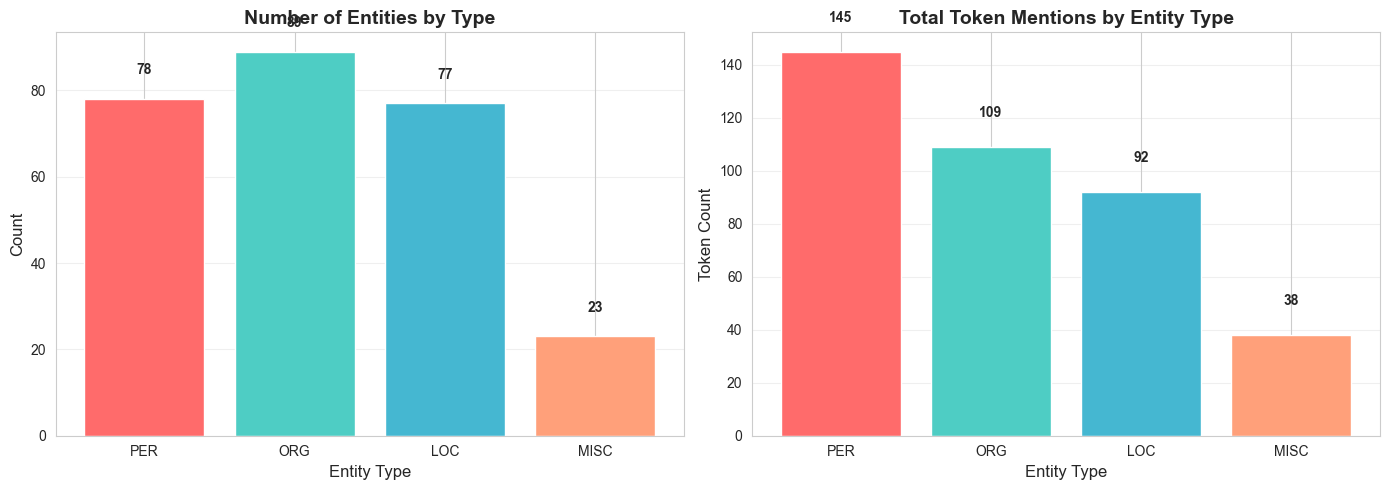

In [20]:
# Visualize entity distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Entity counts
entity_types = list(entity_counts.keys())
counts = list(entity_counts.values())

axes[0].bar(entity_types, counts, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A'])
axes[0].set_title('Number of Entities by Type', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Entity Type', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(counts):
    axes[0].text(i, v + 5, str(v), ha='center', va='bottom', fontweight='bold')

# Token mentions
mentions = list(entity_mentions.values())
axes[1].bar(entity_types, mentions, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A'])
axes[1].set_title('Total Token Mentions by Entity Type', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Entity Type', fontsize=12)
axes[1].set_ylabel('Token Count', fontsize=12)
axes[1].grid(axis='y', alpha=0.3)
for i, v in enumerate(mentions):
    axes[1].text(i, v + 10, str(v), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()


## 3. Sentence Length Distribution


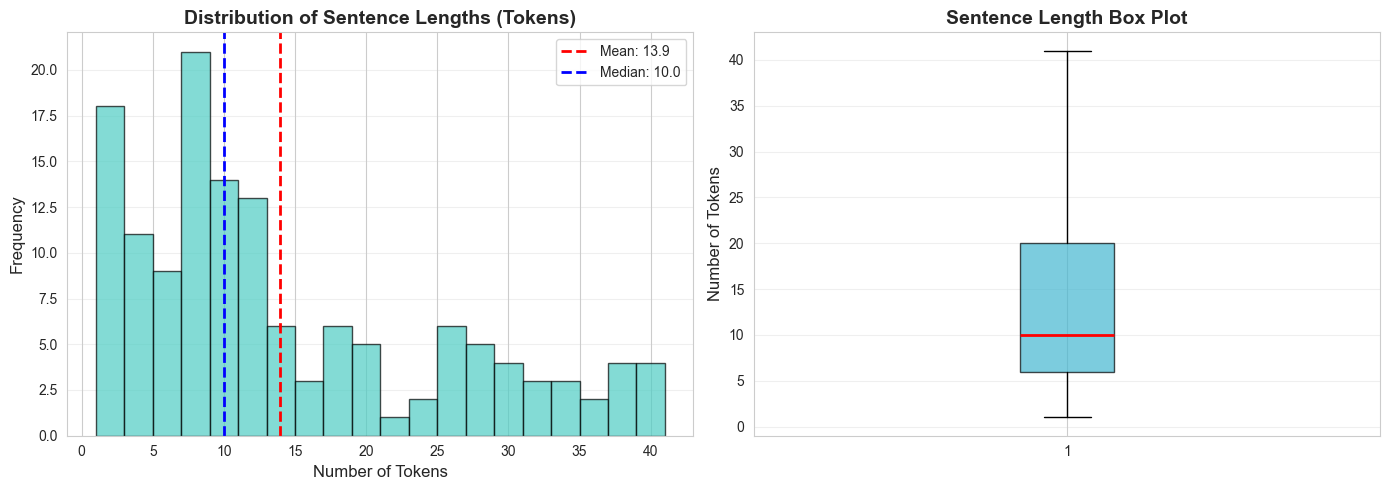

In [21]:
# Visualize sentence length distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(sentence_lengths, bins=20, color='#4ECDC4', edgecolor='black', alpha=0.7)
axes[0].axvline(np.mean(sentence_lengths), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(sentence_lengths):.1f}')
axes[0].axvline(np.median(sentence_lengths), color='blue', linestyle='--', linewidth=2, label=f'Median: {np.median(sentence_lengths):.1f}')
axes[0].set_title('Distribution of Sentence Lengths (Tokens)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of Tokens', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Box plot
axes[1].boxplot(sentence_lengths, vert=True, patch_artist=True,
                boxprops=dict(facecolor='#45B7D1', alpha=0.7),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Sentence Length Box Plot', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Number of Tokens', fontsize=12)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


## 4. Label Distribution Analysis


In [22]:
# Count all label types
all_labels = []
for item in data:
    all_labels.extend(item['labels'])

label_counts = Counter(all_labels)

print("Label Distribution:")
print("=" * 50)
for label, count in label_counts.most_common():
    percentage = (count / len(all_labels)) * 100
    print(f"{label:15s}: {count:5d} ({percentage:5.2f}%)")


Label Distribution:
O              :  1564 (80.29%)
I-PER          :   145 ( 7.44%)
I-ORG          :   109 ( 5.60%)
I-LOC          :    92 ( 4.72%)
I-MISC         :    38 ( 1.95%)


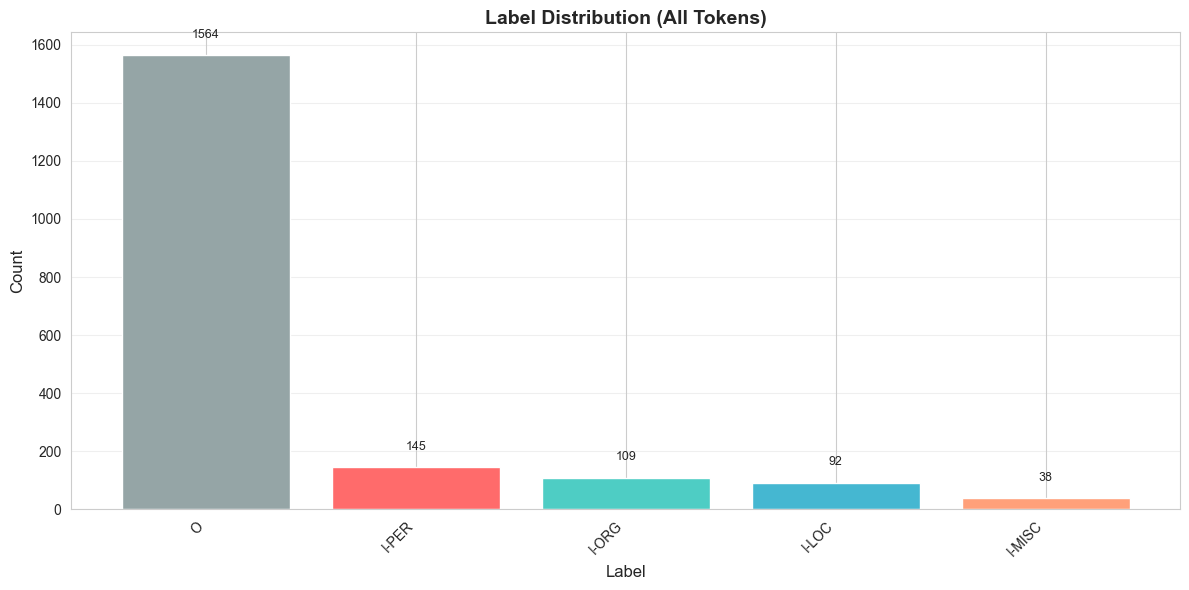

In [23]:
# Visualize label distribution
labels = list(label_counts.keys())
counts = list(label_counts.values())

# Sort by count
sorted_data = sorted(zip(labels, counts), key=lambda x: x[1], reverse=True)
labels_sorted, counts_sorted = zip(*sorted_data)

plt.figure(figsize=(12, 6))
bars = plt.bar(range(len(labels_sorted)), counts_sorted, 
               color=['#FF6B6B' if 'PER' in l else '#4ECDC4' if 'ORG' in l else '#45B7D1' if 'LOC' in l else '#FFA07A' if 'MISC' in l else '#95A5A6' for l in labels_sorted])
plt.xticks(range(len(labels_sorted)), labels_sorted, rotation=45, ha='right')
plt.title('Label Distribution (All Tokens)', fontsize=14, fontweight='bold')
plt.xlabel('Label', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.grid(axis='y', alpha=0.3)

# Add count labels on bars
for i, (bar, count) in enumerate(zip(bars, counts_sorted)):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             str(count), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


## 5. Entity Coverage Analysis


In [24]:
# Analyze how many sentences contain each entity type
sentences_with_entity = {'PER': 0, 'ORG': 0, 'LOC': 0, 'MISC': 0}

for item in data:
    labels = item['labels']
    found_entities = set()
    prev_label = None
    
    for label in labels:
        if label.startswith('B-'):
            entity_type = label[2:]
            if entity_type in sentences_with_entity:
                found_entities.add(entity_type)
        elif label.startswith('I-'):
            entity_type = label[2:]
            # Check if this I- starts a new entity (after O or different entity)
            if prev_label is None or prev_label == 'O' or (prev_label.startswith('I-') and prev_label[2:] != entity_type):
                if entity_type in sentences_with_entity:
                    found_entities.add(entity_type)
        prev_label = label
    
    for entity_type in found_entities:
        sentences_with_entity[entity_type] += 1

print("Sentences Containing Each Entity Type:")
print("=" * 50)
for entity_type, count in sentences_with_entity.items():
    percentage = (count / len(data)) * 100
    print(f"{entity_type}: {count:3d} sentences ({percentage:5.2f}%)")


Sentences Containing Each Entity Type:
PER:  42 sentences (30.00%)
ORG:  59 sentences (42.14%)
LOC:  60 sentences (42.86%)
MISC:  23 sentences (16.43%)


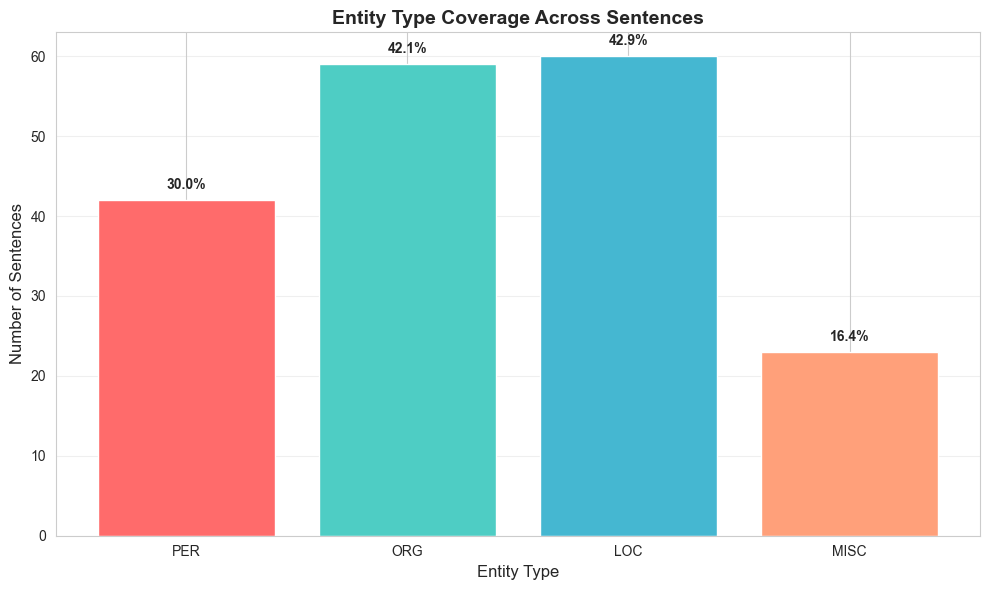

In [25]:
# Visualize entity coverage
entity_types = list(sentences_with_entity.keys())
coverage = list(sentences_with_entity.values())
percentages = [(c / len(data)) * 100 for c in coverage]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(entity_types, coverage, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A'])
ax.set_title('Entity Type Coverage Across Sentences', fontsize=14, fontweight='bold')
ax.set_xlabel('Entity Type', fontsize=12)
ax.set_ylabel('Number of Sentences', fontsize=12)
ax.grid(axis='y', alpha=0.3)

# Add percentage labels
for bar, pct in zip(bars, percentages):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 1,
            f'{pct:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()


## 6. Sample Sentences


In [26]:
# Display sample sentences with entities highlighted
def highlight_entities(tokens, labels):
    """Create a formatted string with entity highlighting"""
    result = []
    for token, label in zip(tokens, labels):
        if label.startswith('B-'):
            result.append(f"[{token}]_{label[2:]}")
        elif label.startswith('I-'):
            result.append(f"{token}_{label[2:]}")
        else:
            result.append(token)
    return ' '.join(result)

print("Sample Sentences with Entities:")
print("=" * 80)
print("Format: [token]_TYPE for B- labels, token_TYPE for I- labels")
print()

# Find sentences with different entity types
samples = []
entity_types_found = set()

for item in data:
    labels = item['labels']
    entities_in_sentence = set()
    for label in labels:
        if label.startswith('B-'):
            entities_in_sentence.add(label[2:])
    
    if len(entities_in_sentence) > 0 and not entities_in_sentence.issubset(entity_types_found):
        samples.append(item)
        entity_types_found.update(entities_in_sentence)
        if len(samples) >= 5:
            break

for i, item in enumerate(samples, 1):
    print(f"\nSample {i}:")
    print(f"Text: {item['text']}")
    print(f"Entities: {highlight_entities(item['tokens'], item['labels'])}")
    print(f"Labels: {item['labels']}")


Sample Sentences with Entities:
Format: [token]_TYPE for B- labels, token_TYPE for I- labels



## 7. Entity Length Analysis


In [27]:
# Analyze entity lengths (number of tokens per entity)
entity_lengths = {'PER': [], 'ORG': [], 'LOC': [], 'MISC': []}

for item in data:
    labels = item['labels']
    current_entity = None
    current_length = 0
    prev_label = None
    
    for label in labels:
        if label.startswith('B-'):
            if current_entity is not None:
                entity_lengths[current_entity].append(current_length)
            entity_type = label[2:]
            if entity_type in entity_lengths:
                current_entity = entity_type
                current_length = 1
        elif label.startswith('I-'):
            entity_type = label[2:]
            # Check if this I- starts a new entity
            if prev_label is None or prev_label == 'O' or (prev_label.startswith('I-') and prev_label[2:] != entity_type):
                # New entity starting with I-
                if current_entity is not None:
                    entity_lengths[current_entity].append(current_length)
                if entity_type in entity_lengths:
                    current_entity = entity_type
                    current_length = 1
            elif entity_type == current_entity:
                # Continuation of same entity
                current_length += 1
            else:
                # Different entity type
                if current_entity is not None:
                    entity_lengths[current_entity].append(current_length)
                if entity_type in entity_lengths:
                    current_entity = entity_type
                    current_length = 1
        else:
            if current_entity is not None:
                entity_lengths[current_entity].append(current_length)
                current_entity = None
                current_length = 0
        
        prev_label = label
    
    # Handle entity at end of sentence
    if current_entity is not None:
        entity_lengths[current_entity].append(current_length)

print("Entity Length Statistics (tokens per entity):")
print("=" * 60)
for entity_type in ['PER', 'ORG', 'LOC', 'MISC']:
    lengths = entity_lengths[entity_type]
    if lengths:
        print(f"\n{entity_type}:")
        print(f"  Count: {len(lengths)}")
        print(f"  Mean: {np.mean(lengths):.2f}")
        print(f"  Median: {np.median(lengths):.2f}")
        print(f"  Min: {np.min(lengths)}")
        print(f"  Max: {np.max(lengths)}")


Entity Length Statistics (tokens per entity):

PER:
  Count: 78
  Mean: 1.86
  Median: 2.00
  Min: 1
  Max: 7

ORG:
  Count: 89
  Mean: 1.22
  Median: 1.00
  Min: 1
  Max: 5

LOC:
  Count: 77
  Mean: 1.19
  Median: 1.00
  Min: 1
  Max: 2

MISC:
  Count: 23
  Mean: 1.65
  Median: 1.00
  Min: 1
  Max: 4


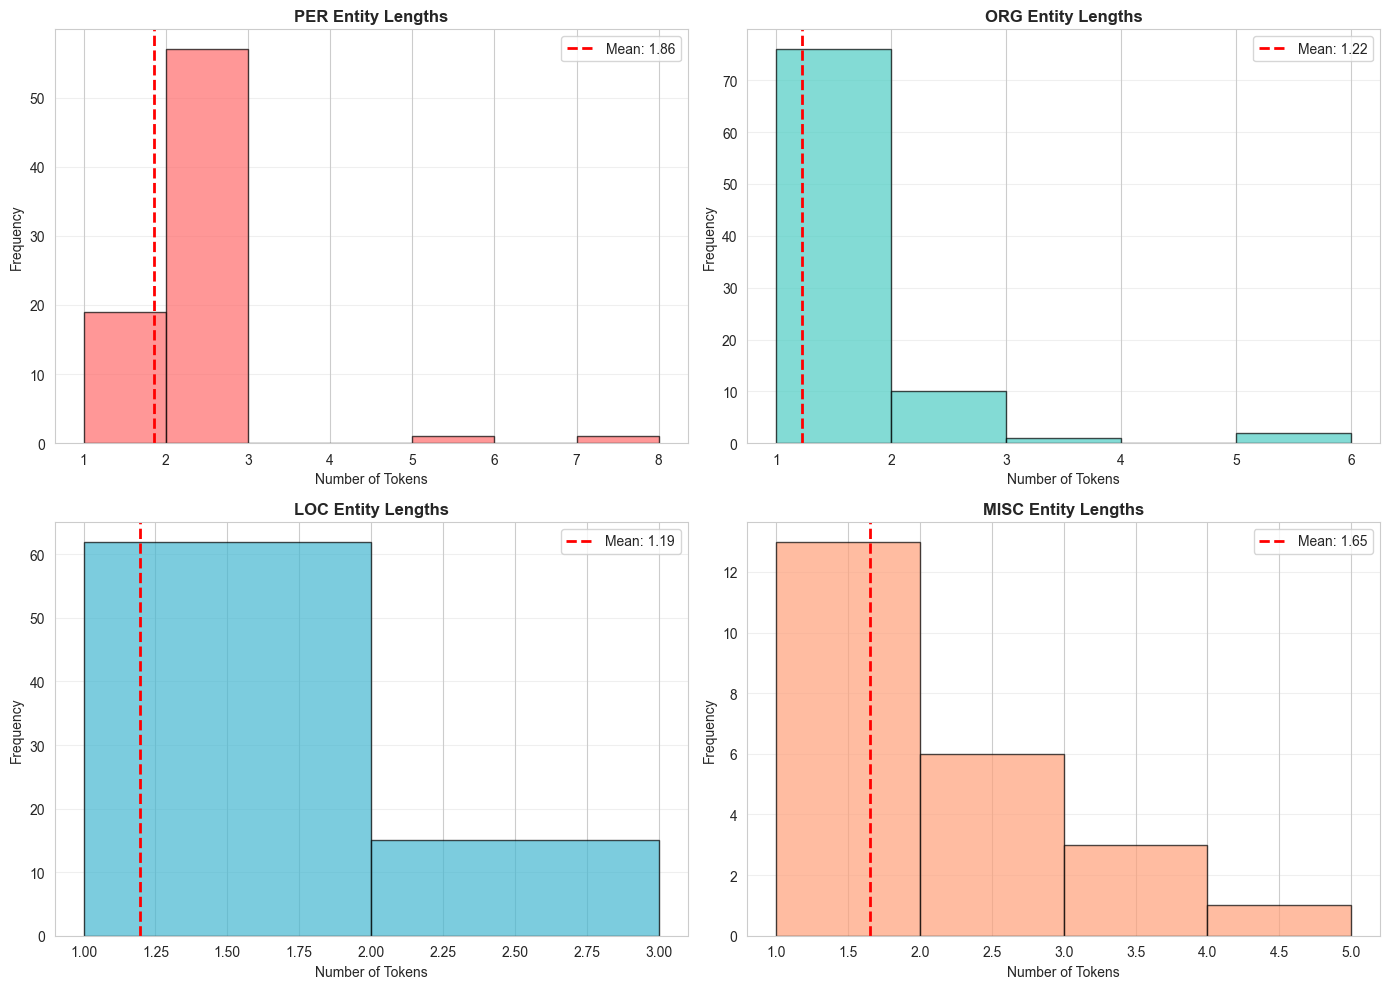

In [28]:
# Visualize entity length distribution
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, entity_type in enumerate(['PER', 'ORG', 'LOC', 'MISC']):
    lengths = entity_lengths[entity_type]
    if lengths:
        axes[idx].hist(lengths, bins=range(1, max(lengths)+2), 
                      color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A'][idx],
                      edgecolor='black', alpha=0.7)
        axes[idx].axvline(np.mean(lengths), color='red', linestyle='--', 
                         linewidth=2, label=f'Mean: {np.mean(lengths):.2f}')
        axes[idx].set_title(f'{entity_type} Entity Lengths', fontsize=12, fontweight='bold')
        axes[idx].set_xlabel('Number of Tokens', fontsize=10)
        axes[idx].set_ylabel('Frequency', fontsize=10)
        axes[idx].legend()
        axes[idx].grid(axis='y', alpha=0.3)
    else:
        axes[idx].text(0.5, 0.5, 'No entities found', 
                      ha='center', va='center', fontsize=12)
        axes[idx].set_title(f'{entity_type} Entity Lengths', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


## 8. Summary Statistics Table


In [29]:
# Create a comprehensive summary table
summary_data = {
    'Entity Type': ['PER', 'ORG', 'LOC', 'MISC', 'Total'],
    'Entity Count': [entity_counts['PER'], entity_counts['ORG'], 
                    entity_counts['LOC'], entity_counts['MISC'],
                    sum(entity_counts.values())],
    'Token Mentions': [entity_mentions['PER'], entity_mentions['ORG'],
                      entity_mentions['LOC'], entity_mentions['MISC'],
                      sum(entity_mentions.values())],
    'Sentences with Entity': [sentences_with_entity['PER'], 
                             sentences_with_entity['ORG'],
                             sentences_with_entity['LOC'],
                             sentences_with_entity['MISC'],
                             len(data)],
    'Avg Entity Length': [
        np.mean(entity_lengths['PER']) if entity_lengths['PER'] else 0,
        np.mean(entity_lengths['ORG']) if entity_lengths['ORG'] else 0,
        np.mean(entity_lengths['LOC']) if entity_lengths['LOC'] else 0,
        np.mean(entity_lengths['MISC']) if entity_lengths['MISC'] else 0,
        np.mean([np.mean(entity_lengths[et]) for et in ['PER', 'ORG', 'LOC', 'MISC'] 
                if entity_lengths[et]])
    ]
}

df_summary = pd.DataFrame(summary_data)
print("\nSummary Statistics Table:")
print("=" * 80)
print(df_summary.to_string(index=False))



Summary Statistics Table:
Entity Type  Entity Count  Token Mentions  Sentences with Entity  Avg Entity Length
        PER            78             145                     42           1.858974
        ORG            89             109                     59           1.224719
        LOC            77              92                     60           1.194805
       MISC            23              38                     23           1.652174
      Total           267             384                    140           1.482668


## 9. Dataset Quality Checks


In [30]:
# Check for potential issues
print("Dataset Quality Checks:")
print("=" * 60)

# Check for I- without B-
i_without_b = 0
for item in data:
    labels = item['labels']
    for i, label in enumerate(labels):
        if label.startswith('I-'):
            if i == 0 or (not labels[i-1].startswith('B-') and not labels[i-1].startswith('I-')):
                i_without_b += 1

print(f"I- labels without preceding B- or I-: {i_without_b}")

# Check for empty sentences
empty_sentences = sum(1 for item in data if len(item['tokens']) == 0)
print(f"Empty sentences: {empty_sentences}")

# Check for label-token mismatch
mismatches = sum(1 for item in data if len(item['tokens']) != len(item['labels']))
print(f"Sentences with token-label mismatch: {mismatches}")

# Check for sentences with no entities
no_entities = sum(1 for item in data if all(not label.startswith('B-') and not label.startswith('I-') for label in item['labels']))
print(f"Sentences with no entities: {no_entities}")

print("\n✓ Quality checks complete!")


Dataset Quality Checks:
I- labels without preceding B- or I-: 264
Empty sentences: 0
Sentences with token-label mismatch: 0
Sentences with no entities: 27

✓ Quality checks complete!


Entity Names (Entity Types)
The 4 categories of named entities:
PER = Person (names of people)
ORG = Organization (companies, teams, institutions)
LOC = Location (places, cities, countries)
MISC = Miscellaneous (dates, events, other named things)
Label Names (BIO Tags)
Labels mark each word in a sentence:
B-PER = Beginning of a Person name
I-PER = Inside/continuation of a Person name
B-ORG = Beginning of an Organization name
I-ORG = Inside/continuation of an Organization name
B-LOC = Beginning of a Location name
I-LOC = Inside/continuation of a Location name
